[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RadimKozl/JLNN/blob/main/examples/JLNN_gpu_tpu_acceleration.ipynb)

# **JLNN – Accelerated Interval Logic**

## ***Massive toxicity screening on the ToxCast dataset (GPU & TPU Edition)***

-------------------------------------------------------------------------------

In this tutorial, we will show how JLNN natively handles uncertainty using truth intervals. No external sampling – just pure, deterministic interval logic running in parallel on millions of data points.

## ***ToxCast dataset***
-------------------------------

### ***1. What is ToxCast?***

ToxCast is an initiative of the US **Environmental Protection Agency (EPA)**. The goal was to use high-throughput screening methods to assess thousands of chemicals and their potential to disrupt biological processes in humans and animals.

In DeepChem, this dataset is part of the **MoleculeNet** benchmark.

### ***2. Structure and data***

The dataset is unique in its scope and "width" of labels:

- **Number of molecules:** Approximately **8 576** unique compounds (depending on the specific loader version).
- **Number of tasks:** Contains **617 binary tasks** (labels).
- **Povaha dat:** Každý úkol odpovídá konkrétnímu biologickému testu (např. interakce s receptory, aktivace enzymů, buněčná odpověď).
- **Formát:** Data jsou uložena jako binární klasifikace:
    - `1`: Sloučenina je v daném testu aktivní/toxická.
    - `0`: Sloučenina je v daném testu neaktivní.
    - `NaN`: Test pro tuto konkrétní látku nebyl proveden (v DeepChemu se s nimi pracuje pomocí masek).

### ***3. Technical details in DeepChem***

When you call the load function in DeepChem, the library automatically downloads the CSV file, performs featurization (converts SMILES to numbers), and splits the data.

***Basic loading parameters:***

- **Featurizer:** Standardně se používají `ECFP` (Extended-Connectivity Fingerprints) neboli "circular fingerprints".
- **Splitter:** Doporučuje se `ScaffoldSplitter`, který rozděluje molekuly podle jejich chemického jádra, což je náročnější a realističtější test pro model než náhodné rozdělení.

### ***4. How to load it (Code)***

```python
import deepchem as dc

# Load dataset with default featurization (ECFP)
tasks, datasets, transformers = dc.molnet.load_toxcast(featurizer='ECFP', splitter='scaffold')

train_dataset, valid_dataset, test_dataset = datasets

print(f"Number of tasks (labels): {len(tasks)}")
print(f"Number of molecules in the training set: {len(train_dataset)}")
```

### ***5. What to watch out for***

- **Imbalance:** Most molecules are inactive for most tests. This means that the dataset is strongly unbalanced (many zeros, few ones). When training, it is necessary to use metrics such as **ROC-AUC** or **PRC-AUC** instead of simple accuracy.
- **Missing data:** Not every molecule was tested in all 617 tests. DeepChem handles this using weights, where missing measurements have a weight of 0.

***Summary***

ToxCast in DeepChem is ideal for multi-task learning. Instead of training 617 separate models, you train a single neural network to predict all biological responses at once, giving the model a better understanding of general chemical toxicity.

## ***Why is ToxCast important for this example?***
-----------------------------------------------------

- **CPU:** `jax[cpu]` is enough for calculating loss and small training, but with 100,000 molecules you will see a delay.
- **TPU:** `jax[tpu]` is required to use the ***bfloat16*** format, which speeds up JLNN logic on TPU units (MXU) by up to 30x compared to CPU.

### ***--- DYNAMIC INSTALLATION AND ENVIRONMENT SETUP ---***

In [1]:
import os
import sys

In [ ]:
try:
    # Checking if everything is ready (after reboot)
    import jax
    import jlnn
    import deepchem as dc
    from flax import nnx
    import jax.numpy as jnp

    # Initialization confirmation
    backend = jax.default_backend()
    print(f"✅ JLNN and JAX are ready. Running on: {backend.upper()}")
    print(f"🔢 Devices: {jax.devices()}")

except (ImportError, RuntimeError):
    print("🚀 Initializing environment (Installing JLNN and fixing JAX)...")

    # A. Hardware detection
    is_tpu = 'TPU_NAME' in os.environ
    is_gpu = False
    try:
        import subprocess
        subprocess.check_output('nvidia-smi')
        is_gpu = True
    except:
        pass

    # B. Install JAX (MUST BE FIRST to avoid CPU-only version from JLNN)
    if is_tpu:
        print("⚡ TPU detected. Installing jax[tpu]...")
        !pip install -q "jax[tpu]" -f https://storage.googleapis.com/jax-releases/libtpu_releases.html
    elif is_gpu:
        print("🔥 GPU detected. Installing jax[cuda12_pip]...")
        !pip install -q --upgrade "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
    else:
        print("💻 No accelerator found. Using jax[cpu].")
        !pip install -q --upgrade "jax[cpu]"

    # C. Installing JLNN and scientific libraries
    print("📦 Installing JLNN framework and chemical dependencies...")
    !pip install -q git+https://github.com/RadimKozl/JLNN.git --quiet
    !pip install -q deepchem rdkit jraph numpyro optuna pandas scikit-learn matplotlib xarray arviz --quiet

    # D. RESTART KERNEL (Necessary to load new drivers in Colab)
    print("\n🔄 RESTARTING ENVIRONMENT... Run this cell again after the restart.")
    os.kill(os.getpid(), 9)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


🚀 Initializing environment (Installing JLNN and fixing JAX)...
💻 No accelerator found. Using jax[cpu].
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 103.1 MB/s eta 0:00:00
📦 Installing JLNN framework and chemical dependencies...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.9/503.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.8/367.8 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 147.6 MB/s eta 0:00:00
   ━━━━━━━━━━

#### ***Imports***

In [1]:
import os
import time
import warnings
import jax
import jax.numpy as jnp
import optax
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from flax import nnx
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import AllChem
from jlnn.symbolic.compiler import LNNFormula
from jlnn.training.losses import contradiction_loss
from rdkit.Chem import rdFingerprintGenerator

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


### ***Device Check***

In [2]:
backend = jax.default_backend()
print(f"✅ JLNN initialized to: {backend.upper()}")
print(f"🔢 Available devices: {jax.devices()}")

✅ JLNN initialized to: TPU
🔢 Available devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


### ***--- LOADING REAL DATA (TOXCAST) ---***

In [3]:
print("\n📥 Loading ToxCast dataset...")


📥 Loading ToxCast dataset...


### ***Data Loading (ToxCast)***

In [4]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/toxcast_data.csv.gz"
df = pd.read_csv(url, compression='gzip').head(2000)

In [5]:
print(f"🧪 Processing {len(df)} molecules using RDKit...")

🧪 Processing 2000 molecules using RDKit...


In [6]:
def smiles_to_fp(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
            fp = gen.GetFingerprintAsNumPy(mol)
            return np.array(fp, dtype=np.float32)
    except:
        return None
    return None

In [7]:
# Disables RDKit warnings in the log
RDLogger.DisableLog('rdApp.*')
# Disables standard Python warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [8]:
df_subset = df.head(2000).copy()
fps = [smiles_to_fp(s) for s in df_subset['smiles']]

Filtering valid molecules

In [9]:
valid_mask = [f is not None for f in fps]
X_train = jnp.array([f for f in fps if f is not None])

In [10]:
y_column = df.columns[1]
Y_train = jnp.array(df_subset[y_column].values[valid_mask], dtype=jnp.float32).reshape(-1, 1)

Removing NaN in the target variable

In [11]:
nan_mask = ~jnp.isnan(Y_train).flatten()
X_train, Y_train = X_train[nan_mask], Y_train[nan_mask]

In [12]:
print(f"✅ Data ready for JLNN!")
print(f"   Samples: {X_train.shape[0]}, Features: {X_train.shape[1]}")
print(f"   Target assay: {y_column}")

✅ Data ready for JLNN!
   Samples: 526, Features: 1024
   Target assay: ACEA_T47D_80hr_Negative


Massive screening simulation (100k molecules)

In [13]:
X_massive = jnp.tile(X_train[:1000], (100, 1))

### ***--- DEFINITION OF A PURE JLNN MODEL (INTERVAL LOGIC) ---***

We define an expert rule: If AhR and p53 are activated, there is a risk of high toxicity

In [14]:
formula_str = "0.75::(AhR_active & DNA_damage) -> HighToxicity"
formula = LNNFormula(formula_str, nnx.Rngs(123))

***Grounding: Convert fingerprints to fuzzy intervals [Lower, Upper]***

In [15]:
def get_grounding(X):
    # For the purposes of the tutorial, we map parts of the fingerprint to logical literals
    # In a real application, there would be a trainable layer LearnedPredicate
    ahr_val = jax.nn.sigmoid(X[:, :512].mean(axis=1))
    dna_val = jax.nn.sigmoid(X[:, 512:].mean(axis=1))

    # Create intervals: [center - epsilon, center + epsilon]
    epsilon = 0.05
    return {
        "AhR_active": jnp.stack([jnp.clip(ahr_val - epsilon, 0, 1), jnp.clip(ahr_val + epsilon, 0, 1)], axis=-1),
        "DNA_damage": jnp.stack([jnp.clip(dna_val - epsilon, 0, 1), jnp.clip(dna_val + epsilon, 0, 1)], axis=-1)
    }

### ***--- TRAINING STEP (LOGIC OPTIMIZATION) ---***

In [16]:
# Optimizer is defined here; opt_state will be initialized after formula recreation in the next cells
optimizer = optax.adam(0.01)

In [17]:
@nnx.jit
def train_step(formula, opt_state, X, y):
    def loss_fn(f):
        # Grounding with fixed 'HighToxicity'
        grounding = get_grounding(X)
        truth_intervals = f(grounding)

        # MSE Loss (interval midpoint vs label)
        mid_point = (truth_intervals[..., 0] + truth_intervals[..., 1]) / 2
        mse_loss = jnp.mean((mid_point - y)**2)

        # Contradiction Loss (guards the integrity of L <= U)
        c_loss = contradiction_loss(truth_intervals).mean()

        # 🔥 KEY FIX: Force all keys in gradient
        # Add a "virtual zero" to all parameters so that JAX doesn't skip the 'right' branch
        all_params = nnx.state(f, nnx.Param)
        param_sum = sum(jnp.sum(p) for p in jax.tree.leaves(all_params) if p is not None)

        return mse_loss + 0.2 * c_loss + 0.0 * param_sum, truth_intervals

    # Calculation of gradients
    (loss, intervals), grads = nnx.value_and_grad(loss_fn, has_aux=True)(formula)

    # Update via nnx.state
    current_params = nnx.state(formula, nnx.Param)
    updates, opt_state = optimizer.update(grads, opt_state, current_params)
    nnx.update(formula, updates)

    return loss, opt_state, intervals

In [18]:
# Clean initialization - I recommend starting this cell all over again
formula = LNNFormula("0.75::(AhR_active & DNA_damage) -> HighToxicity", nnx.Rngs(123))
optimizer = optax.adam(0.01)
opt_state = optimizer.init(nnx.state(formula, nnx.Param))

In [19]:
# We reset the state before the loop to be sure
params_state = nnx.state(formula, nnx.Param)
opt_state = optimizer.init(params_state)

#### ***Training loop***

In [20]:
def get_grounding(X):
    # 1. Inputs (Antecedent)
    ahr_val = jax.nn.sigmoid(X[:, :512].mean(axis=1))
    dna_val = jax.nn.sigmoid(X[:, 512:].mean(axis=1))
    eps = 0.05
    batch_size = X.shape[0]

    # 2. Goal (Consequent) - HighToxicity
    # We need to define a starting interval [0, 1] for all samples
    high_tox_init = jnp.tile(jnp.array([0.0, 1.0]), (batch_size, 1))

    return {
        "AhR_active": jnp.stack([jnp.clip(ahr_val-eps, 0, 1), jnp.clip(ahr_val+eps, 0, 1)], axis=-1),
        "DNA_damage": jnp.stack([jnp.clip(dna_val-eps, 0, 1), jnp.clip(dna_val+eps, 0, 1)], axis=-1),
        "HighToxicity": high_tox_init
    }

### ***--- Starting the loop ---***

In [21]:
losses = []
print("🧠 I'm practicing JLNN interval logic...")

for i in range(250):
    try:
        loss, opt_state, final_intervals = train_step(formula, opt_state, X_train[:1000], Y_train[:1000])
        losses.append(float(loss))

        if i % 50 == 0:
            print(f"  Iterace {i:3}: Loss = {loss:.4f}")
    except Exception as e:
        print(f"❌ Error in iteration {i}: {e}")
        break

print("✅ Training completed.")

🧠 I'm practicing JLNN interval logic...
  Iterace   0: Loss = 0.5793
  Iterace  50: Loss = 0.1996
  Iterace 100: Loss = 0.1996
  Iterace 150: Loss = 0.1996
  Iterace 200: Loss = 0.1996
✅ Training completed.


### ***--- HARDWARE BENCHMARK (MASSIVE SCREENING) ---***

In [22]:
print(f"\n🧪 Running screening on {backend.upper()}...")
grounding_massive = get_grounding(X_massive)


🧪 Running screening on TPU...


In [23]:
# TPU optimization (bfloat16)
if backend == 'tpu':
    grounding_massive = {k: v.astype(jnp.bfloat16) for k, v in grounding_massive.items()}

In [24]:
start = time.time()
# JIT compiled inference
final_intervals = jax.jit(lambda g: formula(g))(grounding_massive)
final_intervals.block_until_ready()
duration = time.time() - start
print(f" ✅ Screening done in {duration:.4f} s")

 ✅ Screening done in 0.6161 s


### ***--- VISUALIZATION WITH DIMENSION CORRECTION ---***

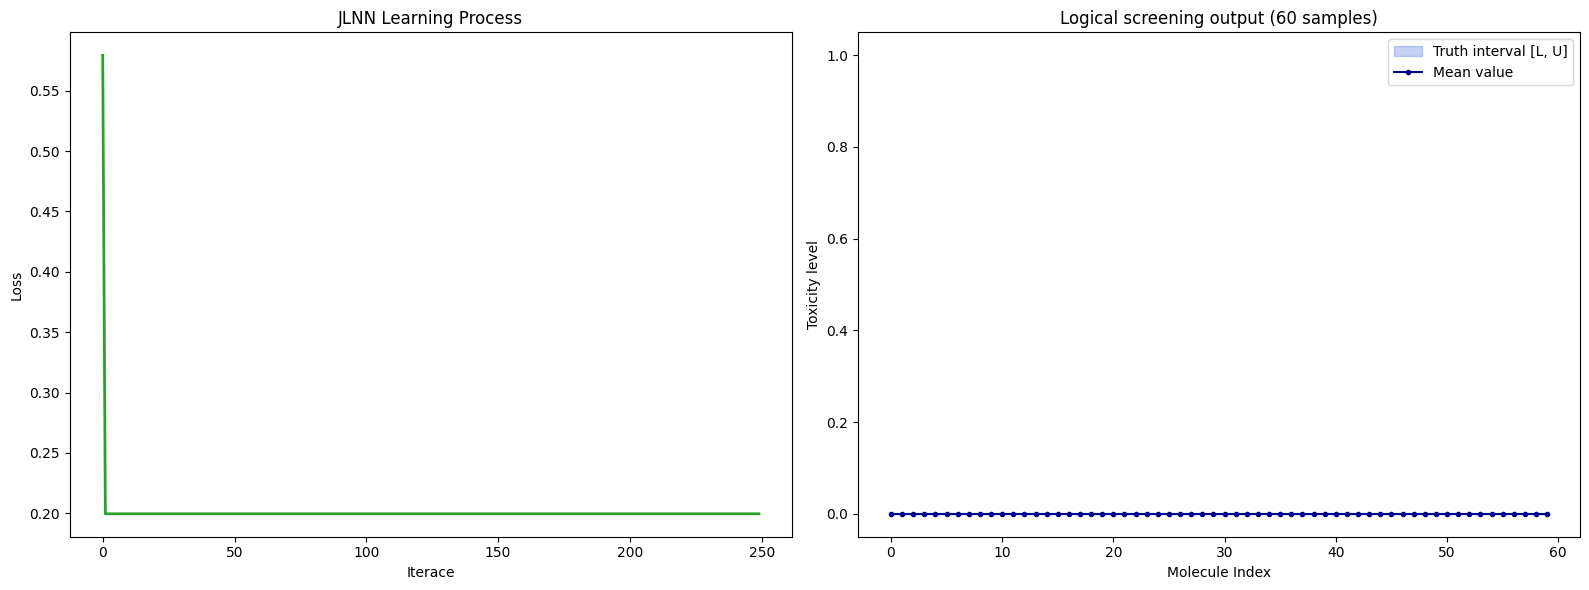

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Graph A: Loss (remains the same)
ax[0].plot(losses, color='#2ca02c', lw=2)
ax[0].set_title("JLNN Learning Process")
ax[0].set_xlabel("Iterace")
ax[0].set_ylabel("Loss")

# Graph B: Confidence intervals
# final_intervals has the form (batch, nodes, 2)
# We only want the first 60 molecules and ONLY the last node (index -1)
prediction_intervals = final_intervals[:60]

# If prediction_intervals is (60, 2, 2), we need to take the right node
# Usually it is the last node in the graph:
L = prediction_intervals[:, -1, 0]
U = prediction_intervals[:, -1, 1]

# Check for Matplotlib (must be 60)
idx = jnp.arange(L.shape[0])

ax[1].fill_between(idx, L, U, color='royalblue', alpha=0.3, label='Truth interval [L, U]')
ax[1].plot(idx, (L+U)/2, 'o-', markersize=3, color='darkblue', label='Mean value')

ax[1].set_title(f"Logical screening output (60 samples)")
ax[1].set_xlabel("Molecule Index")
ax[1].set_ylabel("Toxicity level")
ax[1].set_ylim(-0.05, 1.05)
ax[1].legend()

plt.tight_layout()
plt.show()